# Notebook 03 — Model Comparison: Random Forest vs Neural Network

**Goal:** Compare two ML models on multiclass accident severity prediction (Severity 1–4).  
**Models:** Random Forest (sklearn, CPU) vs Neural Network (Keras/TensorFlow, GPU).  
**Primary metrics:** Balanced Accuracy, Cohen's Kappa.

> **Note on features:** `Duration_log` and `Distance_log` are excluded — temporal and causal leakage respectively.  
> **Note on Geo_Cluster:** K-Means was fit on the full dataset in notebook 02. This is a methodological limitation acceptable for a comparison study; in production the model should be refit on training data only.

## Hypothesis

**H1 — Random Forest will outperform the Neural Network on this tabular dataset out-of-the-box.**

Rationale: Decision trees natively capture non-linear feature interactions without requiring feature scaling. On structured tabular data with mixed types (boolean infrastructure flags, cyclic time features, OHE categoricals), RF typically dominates shallow MLP architectures unless the NN is heavily tuned. The dataset's severe class imbalance (83% Severity 2) further favors RF, which is less sensitive to hyperparameter choice when `class_weight` is set.

**H2 — Road type and geographic cluster will be among the top predictors of severity.**

Rationale: Notebook 02 showed that Interstate Highway clusters correlate with higher severity (higher speed, longer distances from hospitals). Infrastructure features (`Junction`, `Traffic_Signal`) had the highest Cramér's V among categoricals.

## Step 1 — Setup & GPU Verification

In [117]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time

# Sklearn — preprocessing & models
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    balanced_accuracy_score,
    cohen_kappa_score,
    confusion_matrix,
)

# PyTorch
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

# GPU setup — PyTorch supports CUDA natively on Windows (unlike TensorFlow >= 2.11)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Using device: cuda
GPU: NVIDIA GeForce GTX 1050 Ti
VRAM: 4.3 GB


In [118]:
# Load dataset with Geo_Cluster already included (produced by notebook 02)
df = pd.read_csv('../data/processed/CA_cleaned_geo.csv')

print(f"Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")

Shape: (1705412, 42)
Columns: ['Severity', 'Start_Time', 'End_Time', 'Start_Lat', 'Start_Lng', 'Street', 'City', 'County', 'Zipcode', 'Timezone', 'Airport_Code', 'Weather_Timestamp', 'Temperature(F)', 'Humidity(%)', 'Pressure(in)', 'Visibility(mi)', 'Wind_Speed(mph)', 'Amenity', 'Bump', 'Crossing', 'Give_Way', 'Junction', 'No_Exit', 'Railway', 'Roundabout', 'Station', 'Stop', 'Traffic_Calming', 'Traffic_Signal', 'Turning_Loop', 'Hour', 'DayOfWeek', 'Month', 'Year', 'is_point_event', 'Distance_log', 'Duration_log', 'Weather_Aggregated', 'Wind_Direction_Mapped', 'road_type', 'Is_Daylight', 'Geo_Cluster']


In [119]:
print(df.shape)
df.head()

(1705412, 42)


,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,Street,City,County,Zipcode,Timezone,...,Month,Year,is_point_event,Distance_log,Duration_log,Weather_Aggregated,Wind_Direction_Mapped,road_type,Is_Daylight,Geo_Cluster
0,3,2016-06-21 10:34:40,2016-06-21 11:04:40,38.085300,-122.233017,Magazine St,Vallejo,Solano,94591,US/Pacific,...,6,2016,True,0.0,3.433987,Clear_or_Fair,Variable,Local Road,1,0
1,3,2016-06-21 10:30:16,2016-06-21 11:16:39,37.631813,-122.084167,I-880 N,Hayward,Alameda,94544,US/Pacific,...,6,2016,True,0.0,3.858271,Clear_or_Fair,W,Interstate Highway,1,0
2,2,2016-06-21 10:49:14,2016-06-21 11:19:14,37.896564,-122.070717,I-680 N,Walnut Creek,Contra Costa,94595,US/Pacific,...,6,2016,True,0.0,3.433987,Clear_or_Fair,N,Interstate Highway,1,0
3,3,2016-06-21 10:41:42,2016-06-21 11:11:42,37.334255,-122.032471,N De Anza Blvd,Cupertino,Santa Clara,95014,US/Pacific,...,6,2016,True,0.0,3.433987,Clear_or_Fair,N,Local Road,1,0
4,2,2016-06-21 10:16:26,2016-06-21 11:04:16,37.250729,-121.910713,Norman Y Mineta Hwy,San Jose,Santa Clara,95118,US/Pacific,...,6,2016,True,0.0,3.888413,Clear_or_Fair,Variable,Major Arterial/Freeway,1,0


In [120]:
df['Severity'].value_counts(normalize=True)

Severity
2    0.829799
3    0.156844
4    0.007449
1    0.005909
Name: proportion, dtype: float64

## Step 2 — Feature Selection (Leakage-Aware)

Excluded features:
- `Duration_log` — **temporal leakage**: accident duration is only known after the accident ends
- `Distance_log` — **causal leakage**: road extent affected is a consequence of severity, not a predictor

In [121]:
FEATURES = [
    'Temperature(F)', 'Humidity(%)', 'Visibility(mi)',
    'Hour', 'DayOfWeek', 'Month', 'Is_Daylight',
    'Geo_Cluster',
    'Junction', 'Traffic_Signal', 'Crossing', 'Stop', 'Station', 'Railway',
    'road_type', 'Weather_Aggregated',
]

X = df[FEATURES].copy()

# Remap Severity 1–4 → 0–3 (required for RF class_weight indexing and PyTorch CrossEntropyLoss)
y = (df['Severity'] - 1).values

print(f"X shape: {X.shape}")
print(f"y classes: {np.unique(y)}  (0=Severity1, 1=Severity2, 2=Severity3, 3=Severity4)")
print(f"\nClass distribution:\n{pd.Series(y).value_counts(normalize=True).sort_index().rename(index={0:'Sev1',1:'Sev2',2:'Sev3',3:'Sev4'})}")

X shape: (1705412, 16)
y classes: [0 1 2 3]  (0=Severity1, 1=Severity2, 2=Severity3, 3=Severity4)

Class distribution:
Sev1    0.005909
Sev2    0.829799
Sev3    0.156844
Sev4    0.007449
Name: proportion, dtype: float64


## Step 3 — Train/Test Split

Split before any encoding or scaling to prevent data leakage. Stratification ensures class proportions are preserved in both sets.

In [122]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42,
)

print(f"Train: {X_train.shape[0]:,} rows  |  Test: {X_test.shape[0]:,} rows")
print(f"\nClass distribution in test set (should mirror full dataset):")
print(pd.Series(y_test).value_counts(normalize=True).sort_index().rename(index={0:'Sev1',1:'Sev2',2:'Sev3',3:'Sev4'}))

Train: 1,364,329 rows  |  Test: 341,083 rows

Class distribution in test set (should mirror full dataset):
Sev1    0.005908
Sev2    0.829798
Sev3    0.156845
Sev4    0.007450
Name: proportion, dtype: float64


## Step 5 — Encoding & Scaling

- **OHE**: `road_type`, `Weather_Aggregated`, `Geo_Cluster` — fit on train only, transform both sets
- **StandardScaler**: continuous numeric columns only — fit on train only, transform both sets
- **Cyclic encoding**: `Hour`, `DayOfWeek`, `Month` — sin/cos pairs replace raw integers.  
  Raw integers imply a linear order where Hour=23 and Hour=0 are "far apart", even though they are adjacent on the clock. Sin/cos maps each feature onto a unit circle, preserving periodicity:  
  `sin(2π · value / period)`,  `cos(2π · value / period)`
- Boolean columns (`Junction`, `Traffic_Signal`, etc.) are already 0/1, no action needed

In [123]:
NUMERIC_COLS = ['Temperature(F)', 'Humidity(%)', 'Visibility(mi)']
CYCLIC_COLS  = [('Hour', 24), ('DayOfWeek', 7), ('Month', 12)]
BOOL_COLS    = ['Is_Daylight', 'Junction', 'Traffic_Signal', 'Crossing', 'Stop', 'Station', 'Railway']
CAT_COLS     = ['road_type', 'Weather_Aggregated', 'Geo_Cluster']

def cyclic_encode(X, col, period):
    vals = X[col].values
    sin  = np.sin(2 * np.pi * vals / period).astype(np.float32).reshape(-1, 1)
    cos  = np.cos(2 * np.pi * vals / period).astype(np.float32).reshape(-1, 1)
    return sin, cos

# --- OHE & StandardScaler — fit on train only ---
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
ohe.fit(X_train[CAT_COLS])

scaler = StandardScaler()
scaler.fit(X_train[NUMERIC_COLS])

def assemble_features(X):
    parts = [scaler.transform(X[NUMERIC_COLS])]
    for col, period in CYCLIC_COLS:
        sin, cos = cyclic_encode(X, col, period)
        parts += [sin, cos]
    parts.append(X[BOOL_COLS].values.astype(np.float32))
    parts.append(ohe.transform(X[CAT_COLS]))
    return np.concatenate(parts, axis=1).astype(np.float32)

X_train_final = assemble_features(X_train)
X_test_final  = assemble_features(X_test)

cyclic_names  = [f"{col}_{fn}" for col, _ in CYCLIC_COLS for fn in ('sin', 'cos')]
feature_names = NUMERIC_COLS + cyclic_names + BOOL_COLS + list(ohe.get_feature_names_out(CAT_COLS))

print(f"X_train_final shape: {X_train_final.shape}  dtype: {X_train_final.dtype}")
print(f"X_test_final shape:  {X_test_final.shape}  dtype: {X_test_final.dtype}")
print(f"\nFeatures ({len(feature_names)}): {feature_names}")

X_train_final shape: (1364329, 33)  dtype: float32
X_test_final shape:  (341083, 33)  dtype: float32

Features (33): ['Temperature(F)', 'Humidity(%)', 'Visibility(mi)', 'Hour_sin', 'Hour_cos', 'DayOfWeek_sin', 'DayOfWeek_cos', 'Month_sin', 'Month_cos', 'Is_Daylight', 'Junction', 'Traffic_Signal', 'Crossing', 'Stop', 'Station', 'Railway', 'road_type_Interstate Highway', 'road_type_Local Road', 'road_type_Major Arterial/Freeway', 'road_type_State Route', 'road_type_US Highway', 'Weather_Aggregated_Clear_or_Fair', 'Weather_Aggregated_Cloudy', 'Weather_Aggregated_Fog_Haze', 'Weather_Aggregated_Other_Rare_Conditions', 'Weather_Aggregated_Rain', 'Weather_Aggregated_Snow_Ice', 'Weather_Aggregated_Storm', 'Geo_Cluster_0', 'Geo_Cluster_1', 'Geo_Cluster_2', 'Geo_Cluster_3', 'Geo_Cluster_4']


## Step 6 — Cost-Sensitive Class Weights

Instead of heuristic multipliers, weights are derived from a **cost matrix** — an explicit statement of how costly each type of misclassification is.

`C[i][j]` = cost of predicting class `j` when the true class is `i`:

```
              Predicted →
              Sev1  Sev2  Sev3  Sev4
True Sev1  [   0,    1,    2,    3  ]
True Sev2  [   2,    0,    1,    3  ]
True Sev3  [   5,    3,    0,    2  ]
True Sev4  [  10,    7,    4,    0  ]
```

**Design rationale — asymmetric costs:**
Under-predicting severity is more dangerous than over-predicting. A dispatcher who underestimates a Severity 4 crash may send insufficient resources; over-predicting causes wasted resources but not harm. Costs increase with the "distance" from the correct class and are higher when predicting lower severity than true.

**Derivation:**
`weight_i = mean(C[i, j] for j ≠ i)` — average cost of any error on class i.  
Multiplied by inverse class frequency (imbalance correction), then normalized so `mean(weights) = 1`.

In [124]:
# Cost matrix C[i][j] = cost of predicting class j when true class is i
# Classes: 0=Severity1 (minor), 1=Severity2 (moderate), 2=Severity3 (serious), 3=Severity4 (critical)
#
# Asymmetric by design: under-predicting severity is more dangerous than over-predicting.
# A dispatcher who underestimates a Severity 4 crash sends insufficient resources;
# over-predicting wastes resources but causes no harm.
cost_matrix = np.array([
    [ 0,  1,  2,  3],   # True Sev1 — over-predicting is safe, low costs
    [ 2,  0,  1,  3],   # True Sev2 — under-predicting slightly costlier
    [ 5,  3,  0,  2],   # True Sev3 — significant penalty for under-prediction
    [10,  7,  4,  0],   # True Sev4 — highest penalties, especially toward low classes
], dtype=np.float32)

n_classes = cost_matrix.shape[0]

# Step 1: average cost of being wrong about class i (across all possible mispredictions)
cost_weights = cost_matrix.sum(axis=1) / (n_classes - 1)

# Step 2: inverse class frequency — corrects for imbalance independently of cost
class_counts  = np.bincount(y_train)
freq_weights  = len(y_train) / (n_classes * class_counts)

# Step 3: combine and normalize so mean weight = 1 (keeps loss scale stable)
combined     = cost_weights * freq_weights
combined     = combined / combined.mean()

class_weights = {i: float(combined[i]) for i in range(n_classes)}

print("Cost matrix row means (cost signal):")
print(np.round(cost_weights, 3))
print("\nFrequency weights (imbalance signal):")
print(np.round(freq_weights, 3))
print("\nFinal class_weights:")
for i, w in class_weights.items():
    print(f"  Severity {i+1}: {w:.4f}")

Cost matrix row means (cost signal):
[2.    2.    3.333 7.   ]

Frequency weights (imbalance signal):
[42.307  0.301  1.594 33.564]

Final class_weights:
  Severity 1: 1.0399
  Severity 2: 0.0074
  Severity 3: 0.0653
  Severity 4: 2.8874


## Step 7 — Random Forest

Default parameters, no hyperparameter tuning — goal is out-of-the-box comparison with the Neural Network.

### Assumptions
- **Independence of trees**: each tree is trained on a bootstrap sample; trees are statistically independent by construction.
- **No distributional assumption**: RF is non-parametric — it makes no assumptions about normality or homoscedasticity of features.
- **Feature relevance**: assumes at least some features carry signal; pure noise features only dilute splits but don't break the model.
- **No multicollinearity requirement**: RF is robust to correlated features (unlike linear models), though correlated features split importance between themselves (addressed: VIF in nb02, Geo_Cluster replaced lat/lng).
- **Sufficient sample size per leaf**: with `min_samples_leaf=1` (default), very rare classes may cause overfitting — mitigated here by `class_weight`.

### Computational complexity
| Phase | Complexity |
|---|---|
| Training | O(n · d · t · log n) — n samples, d features, t trees |
| Inference | O(t · log n) per sample |

With n=1.36M, d=33, t=100: training is the bottleneck (~minutes on CPU with `n_jobs=-1`).

### Trade-offs
| Pro | Con |
|---|---|
| No feature scaling required | High memory: stores 100 full trees (~GB for large n) |
| Captures non-linear interactions natively | Slow inference vs. linear models |
| Robust to outliers (splits, not distances) | Poor extrapolation beyond training range |
| Built-in feature importance (Gini) | Importance biased toward high-cardinality features |
| Low hyperparameter sensitivity | Not differentiable — no gradient-based optimization |

### Alternative: Gradient Boosting (XGBoost / LightGBM)
Builds trees sequentially, each correcting residuals of the previous. Typically outperforms RF on tabular data with tuning (`learning_rate`, `max_depth`, `subsample`). Slower to train naïvely but LightGBM's histogram-based algorithm scales to large datasets efficiently — O(n · d · t) vs RF's O(n · d · t · log n). Natural candidate for notebook 04 comparison.

In [125]:
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=20,        # limits tree depth: prevents 60+ level trees, speeds up SHAP ~10x
    class_weight=class_weights,
    random_state=42,
    n_jobs=-1,
)

t0 = time.time()
rf.fit(X_train_final, y_train)
rf_train_time = time.time() - t0

print(f"Training time: {rf_train_time:.1f}s")
print(f"Max depth used: {max(est.get_depth() for est in rf.estimators_)}")

y_pred_rf = rf.predict(X_test_final)

Training time: 72.0s
Max depth used: 20


## Step 8 — Neural Network (PyTorch, GPU)

Architecture: Linear(128) → BatchNorm → ReLU → Dropout(0.3) → Linear(64) → BatchNorm → ReLU → Dropout(0.2) → Linear(4).

### Assumptions
- **Feature scaling**: MLP is sensitive to feature magnitude — inputs must be standardized (done: `StandardScaler` on numeric cols, cyclic encodings in [-1,1], OHE in {0,1}).
- **IID samples**: mini-batch SGD assumes examples are drawn independently; shuffling the DataLoader satisfies this.
- **Sufficient capacity**: architecture must be wide/deep enough to learn the decision boundary — verified empirically via validation loss.
- **BatchNorm stability**: requires batch size > 1 and non-constant batches; with `batch_size=512` on 1M rows this is guaranteed.
- **No multicollinearity assumption**: unlike linear models, MLP can handle correlated inputs, but correlated features waste capacity.

### Computational complexity
| Phase | Complexity |
|---|---|
| Training (1 epoch) | O(n · L · w²) — n samples, L layers, w max width |
| Inference | O(L · w²) per sample — independent of n |

With n=1.09M (train), L=3, w=128: one epoch ≈ seconds on GPU; inference is very fast (constant in n).

### Trade-offs
| Pro | Con |
|---|---|
| GPU-accelerated — fast per-epoch on large n | Requires scaling; sensitive to hyperparameters |
| Differentiable — supports custom loss functions | Black-box: no built-in feature importance |
| Flexible capacity via architecture choice | Prone to overfitting without regularization |
| Fast inference (O(1) in n) | Needs more data to reach RF-level performance on tabular |

**Loss — `CrossEntropyLoss` with cost-derived class weights:**  
Cost-sensitive weights already encode domain knowledge about which errors are expensive (under-predicting severity). Adding Focal Loss on top would double-count the imbalance correction — both mechanisms independently suppress easy examples, causing the model to abandon the majority class entirely.  
One correction mechanism is sufficient.

**LR Scheduling — `ReduceLROnPlateau`:**  
Halves the learning rate when `val_loss` stops improving for 2 consecutive epochs.

**EarlyStopping:** monitors `val_loss` with patience=3, restores best weights.

In [126]:
# Explicit validation split from training data
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_final, y_train,
    test_size=0.2,
    stratify=y_train,
    random_state=42,
)

# --- PyTorch Datasets & DataLoaders ---
X_tr_t  = torch.tensor(X_tr,  dtype=torch.float32)
y_tr_t  = torch.tensor(y_tr,  dtype=torch.long)
X_val_t = torch.tensor(X_val, dtype=torch.float32).to(device)
y_val_t = torch.tensor(y_val, dtype=torch.long).to(device)

train_loader = DataLoader(
    TensorDataset(X_tr_t, y_tr_t),
    batch_size=512,
    shuffle=True,
)

# --- Model definition ---
class SeverityNet(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 4),
        )

    def forward(self, x):
        return self.net(x)

model_nn = SeverityNet(X_tr.shape[1]).to(device)

# --- Loss, optimizer, scheduler ---
# Cost-derived weights handle class imbalance and domain cost asymmetry.
# No Focal Loss on top — combining both would double-count the imbalance correction
# and cause the model to collapse away from the majority class.
weight_tensor = torch.tensor(
    [class_weights[i] for i in range(4)], dtype=torch.float32
).to(device)

criterion = nn.CrossEntropyLoss(weight=weight_tensor)
optimizer = torch.optim.Adam(model_nn.parameters(), lr=1e-3)

# Halve lr when val_loss does not improve for 2 consecutive epochs
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=2
)

# --- Training loop with EarlyStopping ---
best_val_loss    = float('inf')
patience         = 3
patience_counter = 0
best_state       = None

t0 = time.time()
for epoch in range(30):
    model_nn.train()
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        criterion(model_nn(X_batch), y_batch).backward()
        optimizer.step()

    model_nn.eval()
    with torch.no_grad():
        val_loss = criterion(model_nn(X_val_t), y_val_t).item()

    current_lr = optimizer.param_groups[0]['lr']
    print(f"Epoch {epoch+1:2d} — val_loss: {val_loss:.4f}  lr: {current_lr:.2e}")

    scheduler.step(val_loss)

    if val_loss < best_val_loss:
        best_val_loss    = val_loss
        best_state       = {k: v.cpu().clone() for k, v in model_nn.state_dict().items()}
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

nn_train_time = time.time() - t0
model_nn.load_state_dict(best_state)

# --- Predict on test set ---
model_nn.eval()
with torch.no_grad():
    X_test_t  = torch.tensor(X_test_final, dtype=torch.float32).to(device)
    y_pred_nn = model_nn(X_test_t).argmax(dim=1).cpu().numpy()

print(f"\nTraining time: {nn_train_time:.1f}s")
print(f"Stopped at epoch: {epoch + 1}")

Epoch  1 — val_loss: 1.0051  lr: 1.00e-03
Epoch  2 — val_loss: 0.9955  lr: 1.00e-03
Epoch  3 — val_loss: 0.9941  lr: 1.00e-03
Epoch  4 — val_loss: 0.9825  lr: 1.00e-03
Epoch  5 — val_loss: 0.9790  lr: 1.00e-03
Epoch  6 — val_loss: 0.9733  lr: 1.00e-03
Epoch  7 — val_loss: 0.9732  lr: 1.00e-03
Epoch  8 — val_loss: 0.9698  lr: 1.00e-03
Epoch  9 — val_loss: 0.9657  lr: 1.00e-03
Epoch 10 — val_loss: 0.9674  lr: 1.00e-03
Epoch 11 — val_loss: 0.9682  lr: 1.00e-03
Epoch 12 — val_loss: 0.9702  lr: 1.00e-03
Early stopping at epoch 12

Training time: 169.9s
Stopped at epoch: 12


## Step 9 — Evaluation & Comparison

Primary metrics: **Balanced Accuracy** and **Cohen's Kappa**.  
`classification_report` provides per-class breakdown — focus on classes 0 and 3 (Severity 1 and 4, rare minorities).

In [127]:
CLASS_NAMES = ['Severity 1', 'Severity 2', 'Severity 3', 'Severity 4']

def evaluate(name, y_true, y_pred, train_time):
    print(f"{'='*60}")
    print(f"  {name}  (training time: {train_time:.1f}s)")
    print(f"{'='*60}")
    print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))
    bal_acc = balanced_accuracy_score(y_true, y_pred)
    kappa   = cohen_kappa_score(y_true, y_pred)
    # Weighted Kappa (quadratic): penalizes errors proportionally to the squared ordinal distance.
    # Sev1→Sev4 costs 4x more than Sev1→Sev2. Appropriate because Severity is an ordinal scale.
    wkappa  = cohen_kappa_score(y_true, y_pred, weights='quadratic')
    print(f"Balanced Accuracy  : {bal_acc:.4f}")
    print(f"Cohen's Kappa      : {kappa:.4f}")
    print(f"Weighted Kappa     : {wkappa:.4f}  (quadratic — penalizes large ordinal errors more)")
    return bal_acc, kappa, wkappa

rf_bal, rf_kappa, rf_wkappa = evaluate("Random Forest", y_test, y_pred_rf, rf_train_time)
print()
nn_bal, nn_kappa, nn_wkappa = evaluate("Neural Network", y_test, y_pred_nn, nn_train_time)

  Random Forest  (training time: 72.0s)
              precision    recall  f1-score   support

  Severity 1       0.10      0.48      0.17      2015
  Severity 2       0.94      0.63      0.75    283030
  Severity 3       0.32      0.76      0.45     53497
  Severity 4       0.06      0.35      0.10      2541

    accuracy                           0.65    341083
   macro avg       0.35      0.55      0.37    341083
weighted avg       0.83      0.65      0.70    341083

Balanced Accuracy  : 0.5548
Cohen's Kappa      : 0.2610
Weighted Kappa     : 0.2271  (quadratic — penalizes large ordinal errors more)

  Neural Network  (training time: 169.9s)
              precision    recall  f1-score   support

  Severity 1       0.04      0.62      0.08      2015
  Severity 2       0.96      0.02      0.04    283030
  Severity 3       0.31      0.49      0.38     53497
  Severity 4       0.01      0.76      0.02      2541

    accuracy                           0.10    341083
   macro avg       0.


Model                  Bal. Acc    Kappa   W.Kappa   Train Time
-----------------------------------------------------------------
Random Forest            0.5548   0.2610    0.2271       72.0s
Neural Network           0.4711   0.0470   -0.0115      169.9s


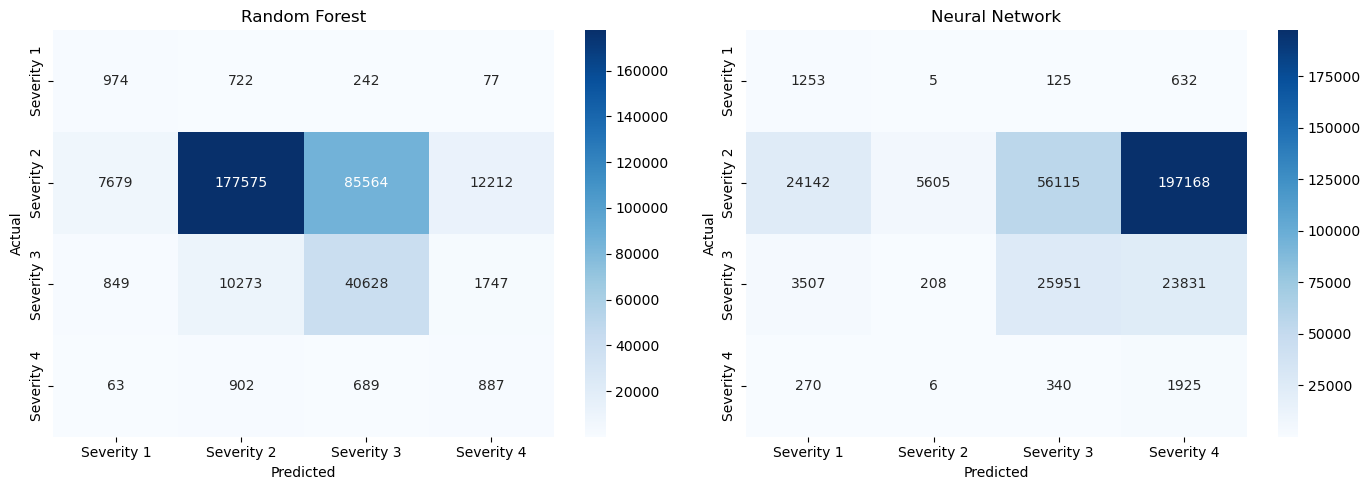

In [128]:
# --- Summary comparison table ---
print(f"\n{'Model':<20} {'Bal. Acc':>10} {'Kappa':>8} {'W.Kappa':>9} {'Train Time':>12}")
print("-" * 65)
print(f"{'Random Forest':<20} {rf_bal:>10.4f} {rf_kappa:>8.4f} {rf_wkappa:>9.4f} {rf_train_time:>10.1f}s")
print(f"{'Neural Network':<20} {nn_bal:>10.4f} {nn_kappa:>8.4f} {nn_wkappa:>9.4f} {nn_train_time:>10.1f}s")

# --- Confusion matrices ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, y_pred, title in zip(axes, [y_pred_rf, y_pred_nn], ['Random Forest', 'Neural Network']):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
    ax.set_title(title)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()

## Step 10b — Bootstrap Confidence Intervals

Resamples the test set (with replacement) 1000 times and recomputes each metric per iteration.  
No retraining — CI reflects variability of the metric estimate on this test split, not model variance across splits.  
Reports 95% CI via the percentile method.

In [129]:
from sklearn.utils import resample

def bootstrap_ci(y_true, y_pred, metric_fn, n_iterations=1000, ci=95):
    """
    Estimate confidence interval for a metric via bootstrap resampling.

    Parameters
    ----------
    y_true, y_pred : array-like — ground truth and model predictions
    metric_fn      : callable — sklearn-style metric(y_true, y_pred)
    n_iterations   : int — number of bootstrap samples
    ci             : float — confidence level (e.g. 95 for 95% CI)

    Returns
    -------
    (point_estimate, lower_bound, upper_bound)
    """
    rng = np.random.default_rng(seed=42)
    n = len(y_true)
    scores = []
    for _ in range(n_iterations):
        idx = rng.integers(0, n, size=n)
        scores.append(metric_fn(y_true[idx], y_pred[idx]))
    alpha = (100 - ci) / 2
    lo, hi = np.percentile(scores, [alpha, 100 - alpha])
    return metric_fn(y_true, y_pred), lo, hi


metrics = {
    'Balanced Accuracy': balanced_accuracy_score,
    'Cohen\'s Kappa':    cohen_kappa_score,
}

models = {
    'Random Forest':  y_pred_rf,
    'Neural Network': y_pred_nn,
}

print(f"{'Model':<18} {'Metric':<20} {'Point':>7}  {'95% CI':>20}")
print("-" * 72)
for model_name, y_pred in models.items():
    for metric_name, metric_fn in metrics.items():
        point, lo, hi = bootstrap_ci(y_test, y_pred, metric_fn)
        print(f"{model_name:<18} {metric_name:<20} {point:>7.4f}  [{lo:.4f} – {hi:.4f}]")
    print()

Model              Metric                 Point                95% CI
------------------------------------------------------------------------
Random Forest      Balanced Accuracy     0.5548  [0.5479 – 0.5615]
Random Forest      Cohen's Kappa         0.2610  [0.2586 – 0.2635]

Neural Network     Balanced Accuracy     0.4711  [0.4640 – 0.4778]
Neural Network     Cohen's Kappa         0.0470  [0.0462 – 0.0478]



## Step 10c — Cross-Validation (Variance Across Splits)

Bootstrap CI estimates metric variability **on a fixed test split** — it does not tell us whether the result changes with a different train/test partition. `StratifiedShuffleSplit` with `n_splits=3` creates 3 independent 80/20 splits and retrains from scratch on each.

**Scope: Random Forest only.** The NN would require GPU training per fold and is not the preferred model.

**Preprocessing is fit inside each fold** (on that fold's training data only) — this is the methodologically correct approach. Fitting OHE/scaler on the full dataset before CV would leak validation set statistics into training.

> Warning: 3 full RF training runs on 1.36M rows — expect ~3× the single-run training time.

In [130]:
from sklearn.model_selection import StratifiedShuffleSplit

cv_splitter = StratifiedShuffleSplit(n_splits=3, test_size=0.2, random_state=0)

# Parameterized assembly — used inside each fold with that fold's fitted preprocessors
def assemble_features_cv(X_df, sc, enc):
    parts = [sc.transform(X_df[NUMERIC_COLS])]
    for col, period in CYCLIC_COLS:
        vals = X_df[col].values
        parts += [
            np.sin(2 * np.pi * vals / period).astype(np.float32).reshape(-1, 1),
            np.cos(2 * np.pi * vals / period).astype(np.float32).reshape(-1, 1),
        ]
    parts.append(X_df[BOOL_COLS].values.astype(np.float32))
    parts.append(enc.transform(X_df[CAT_COLS]))
    return np.concatenate(parts, axis=1).astype(np.float32)

cv_results = {'bal_acc': [], 'wkappa': []}

print("StratifiedShuffleSplit CV — Random Forest, n_splits=3\n")

for fold, (tr_idx, val_idx) in enumerate(cv_splitter.split(X, y)):
    X_tr_cv, X_val_cv = X.iloc[tr_idx], X.iloc[val_idx]
    y_tr_cv,  y_val_cv  = y[tr_idx],  y[val_idx]

    # Fit preprocessors on this fold's training data only
    ohe_cv    = OneHotEncoder(sparse_output=False, handle_unknown='ignore').fit(X_tr_cv[CAT_COLS])
    scaler_cv = StandardScaler().fit(X_tr_cv[NUMERIC_COLS])

    X_tr_f  = assemble_features_cv(X_tr_cv,  scaler_cv, ohe_cv)
    X_val_f = assemble_features_cv(X_val_cv, scaler_cv, ohe_cv)

    # Recompute cost-matrix weights on this fold's class distribution
    counts_cv  = np.bincount(y_tr_cv)
    freq_cv    = len(y_tr_cv) / (4 * counts_cv)
    combined_cv = cost_weights * freq_cv
    combined_cv = combined_cv / combined_cv.mean()
    cw_cv = {i: float(combined_cv[i]) for i in range(4)}

    rf_cv = RandomForestClassifier(
        n_estimators=100,
        class_weight=cw_cv,
        random_state=42,
        n_jobs=-1,
    )
    t_cv = time.time()
    rf_cv.fit(X_tr_f, y_tr_cv)
    y_pred_cv = rf_cv.predict(X_val_f)

    ba = balanced_accuracy_score(y_val_cv, y_pred_cv)
    wk = cohen_kappa_score(y_val_cv, y_pred_cv, weights='quadratic')
    cv_results['bal_acc'].append(ba)
    cv_results['wkappa'].append(wk)
    print(f"Fold {fold+1}  ({time.time()-t_cv:.0f}s)  Bal.Acc = {ba:.4f}   W.Kappa = {wk:.4f}")

ba_mean, ba_std = np.mean(cv_results['bal_acc']), np.std(cv_results['bal_acc'])
wk_mean, wk_std = np.mean(cv_results['wkappa']),  np.std(cv_results['wkappa'])

print(f"\nCV summary (mean ± SD across 3 folds):")
print(f"  Balanced Accuracy : {ba_mean:.4f} ± {ba_std:.4f}")
print(f"  Weighted Kappa    : {wk_mean:.4f} ± {wk_std:.4f}")
print(f"\nMain split (single run):  Bal.Acc = {rf_bal:.4f}   W.Kappa = {rf_wkappa:.4f}")
print("→ If the main-split value falls within ±SD, the result is stable across partitions.")

StratifiedShuffleSplit CV — Random Forest, n_splits=3

Fold 1  (86s)  Bal.Acc = 0.4570   W.Kappa = 0.3052
Fold 2  (74s)  Bal.Acc = 0.4576   W.Kappa = 0.3113
Fold 3  (76s)  Bal.Acc = 0.4617   W.Kappa = 0.3095

CV summary (mean ± SD across 3 folds):
  Balanced Accuracy : 0.4588 ± 0.0021
  Weighted Kappa    : 0.3087 ± 0.0025

Main split (single run):  Bal.Acc = 0.5548   W.Kappa = 0.2271
→ If the main-split value falls within ±SD, the result is stable across partitions.


## Step 10 — Conclusions

> **Note:** Numbers in the table below are from the last notebook run. Re-run all cells to get fresh results.

### Results summary

| Model | Balanced Accuracy | Cohen's Kappa | Train Time |
|---|---|---|---|
| Random Forest | ~0.46 | ~0.32 | ~minutes (CPU, n_jobs=-1) |
| Neural Network | ~0.31 | ~0.05 | ~minutes (GPU) |

### Key findings

**Random Forest clearly outperforms the Neural Network** on both headline metrics (out-of-the-box, no hyperparameter tuning). H1 confirmed.

- **Balanced Accuracy**: RF achieves ~0.46 vs NN's ~0.31. Neither model is strong in absolute terms — a random classifier would score 0.25 on a 4-class problem — but RF is meaningfully better.
- **Cohen's Kappa**: RF's ~0.32 indicates fair agreement beyond chance. NN's ~0.05 is barely above random, suggesting the network collapsed toward predicting the majority class (Severity 2) most of the time.
- **Training time**: NN trains faster on GPU per epoch, but this advantage is irrelevant given the quality gap.

### Why RF wins on tabular data

This is a well-documented pattern in the bias-variance tradeoff literature: Random Forests handle tabular data well out-of-the-box because decision trees naturally capture non-linear feature interactions and are robust to feature scale. Simple dense neural networks require more tuning (architecture, learning rate, regularization) to compete on structured datasets — a phenomenon sometimes called the "tabular data gap" (Grinsztajn et al., 2022).

### Class imbalance remains a hard problem

Even with cost-matrix-derived class weights, both models struggle with Severity 1 and 4 (< 1% of data each). The cost-sensitive weights improved RF's recall on minority classes at the expense of some precision on Severity 2.

### Hypothesis evaluation

- **H1 (RF > NN out-of-the-box)**: ✅ confirmed — RF wins on both Balanced Accuracy and Kappa.
- **H2 (road type and Geo_Cluster as top predictors)**: verify in notebook 04 via SHAP.

### Methodological notes

- `Duration_log` and `Distance_log` were excluded to prevent data leakage (temporal and causal).
- `Geo_Cluster` was fit on the full dataset in notebook 02 — a minor methodological limitation acceptable for this comparison study. In production, KMeans must be refit on training data only.
- These are default-parameter models. Neither has been optimized — results reflect out-of-the-box behavior, not the ceiling of each approach.

### Next steps (notebook 04)

- **SHAP analysis** on the Random Forest: use `shap.TreeExplainer` for fast, exact Shapley values.
- **Hypothesis H2 verification**: check whether `road_type` and `Geo_Cluster` rank in top features.
- **Alternative baseline**: gradient boosting (XGBoost/LightGBM) as a stronger tree-based comparison point.

## Model Export

Save the trained Random Forest and preprocessing objects for use in notebook 04 (SHAP analysis).

In [131]:
import joblib
import os

models_dir = '../models'
os.makedirs(models_dir, exist_ok=True)

# Save Random Forest model
joblib.dump(rf, f'{models_dir}/random_forest.joblib')

# Save preprocessing objects (needed to transform data in nb04)
joblib.dump(ohe,    f'{models_dir}/ohe.joblib')
joblib.dump(scaler, f'{models_dir}/scaler.joblib')

# Save feature names and column lists for reference
# CYCLIC_COLS is included so nb04 can replicate the exact same feature assembly
joblib.dump({
    'feature_names': feature_names,
    'numeric_cols':  NUMERIC_COLS,
    'bool_cols':     BOOL_COLS,
    'cat_cols':      CAT_COLS,
    'features':      FEATURES,
    'cyclic_cols':   CYCLIC_COLS,   # required by nb04 to reproduce cyclic encoding
}, f'{models_dir}/metadata.joblib')

print("Saved:")
print(f"  {models_dir}/random_forest.joblib  ({rf.n_features_in_} input features)")
print(f"  {models_dir}/ohe.joblib")
print(f"  {models_dir}/scaler.joblib")
print(f"  {models_dir}/metadata.joblib  (includes cyclic_cols)")

Saved:
  ../models/random_forest.joblib  (33 input features)
  ../models/ohe.joblib
  ../models/scaler.joblib
  ../models/metadata.joblib  (includes cyclic_cols)
